In [1]:
# we want to store the training data in the required format for directBC.

# we will store the qs as [marker4_x, marker4_y, marker4_z, 0, marker2_x, marker2_y, marker2_z, 0, ee_x, ee_y, ee_z]
# boundary condition is [ee_x, ee_y, ee_z]
# lammbdas can be created using linspace from 0 to 1 with the same length as the trajectories

In [2]:
import json
import numpy as np

n_nodes = "all"
min_marker_presence_ratio = 0.8

traj = 4

if traj == 1:
    file_path = "tape_data/test_ellipse_1_8pts_v5.json"
    drop_first_points = 0
    expected_points = 8 - drop_first_points
    output_path = f"tape_data/11_noded/n11_traj1_tape_dataset_{expected_points}_pts.npz"
elif traj == 2:
    file_path = "tape_data/test_ellipse_2_8pts_v2.json"
    drop_first_points = 0
    expected_points = 8 - drop_first_points
    output_path = f"tape_data/11_noded/n11_traj2_tape_dataset_{expected_points}_pts.npz"
elif traj == 3:
    file_path = "tape_data/test_ellipse_3_8pts_v3.json"
    drop_first_points = 0
    expected_points = 8 - drop_first_points
    output_path = f"tape_data/11_noded/n11_traj3_tape_dataset_{expected_points}_pts.npz"
elif traj == 4:
    file_path = "tape_data/test_ellipse_4_8pts_v1.json"
    drop_first_points = 0
    expected_points = 8 - drop_first_points
    output_path = f"tape_data/11_noded/n11_traj4_tape_dataset_{expected_points}_pts.npz"

Loaded 8 samples
Persistent markers kept: ['marker_0', 'marker_1', 'marker_2', 'marker_3', 'marker_4', 'marker_5', 'marker_6', 'marker_7', 'marker_8', 'marker_9', 'marker_10']
Fixed marker used for origin: marker_10
Markers used in state: ['marker_9', 'marker_8', 'marker_7', 'marker_6', 'marker_5', 'marker_4', 'marker_3', 'marker_2', 'marker_1']
Final node = marker_0 (no end-effector used in state/BCs)


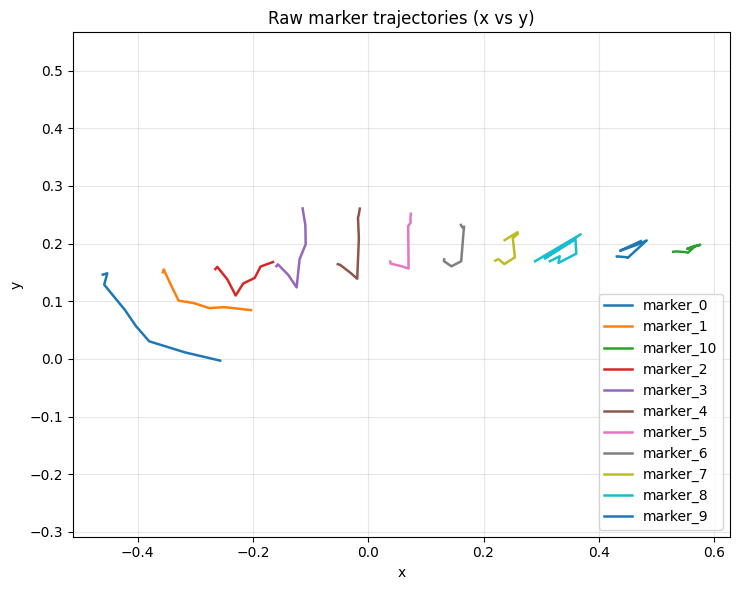

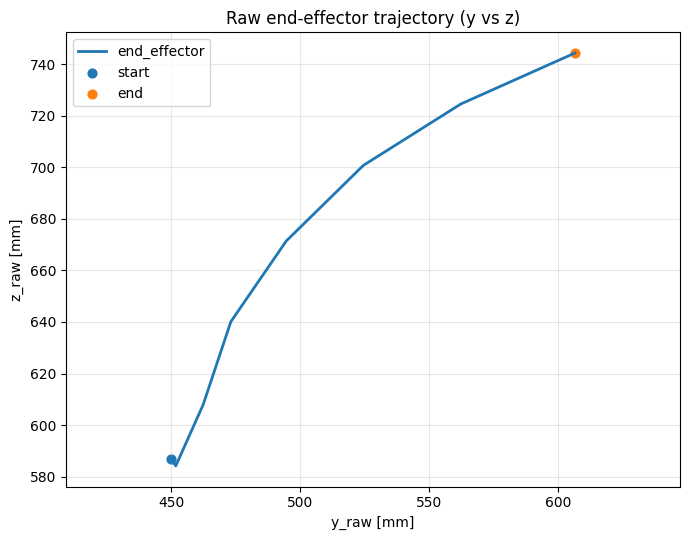

Origin from fixed marker mean:
x0 = 0.5538069423484044
y0 = 0.19011071435076066
z0 = 0.7982246352913135


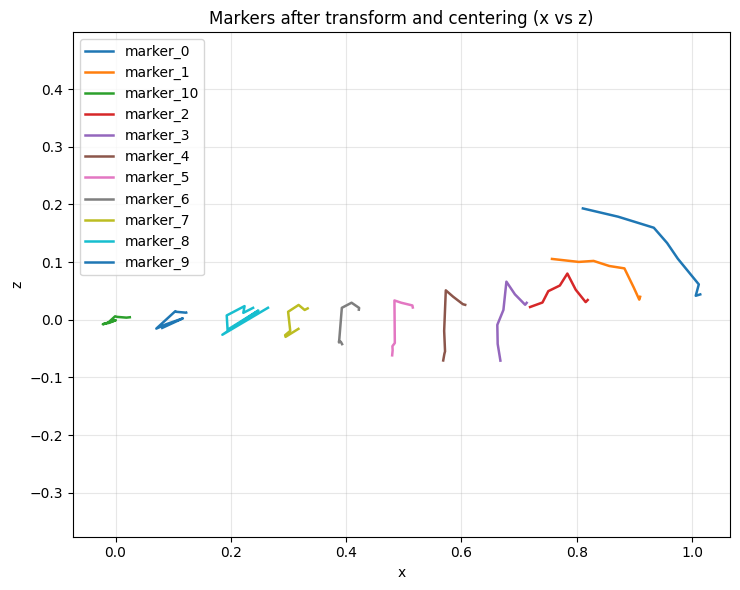

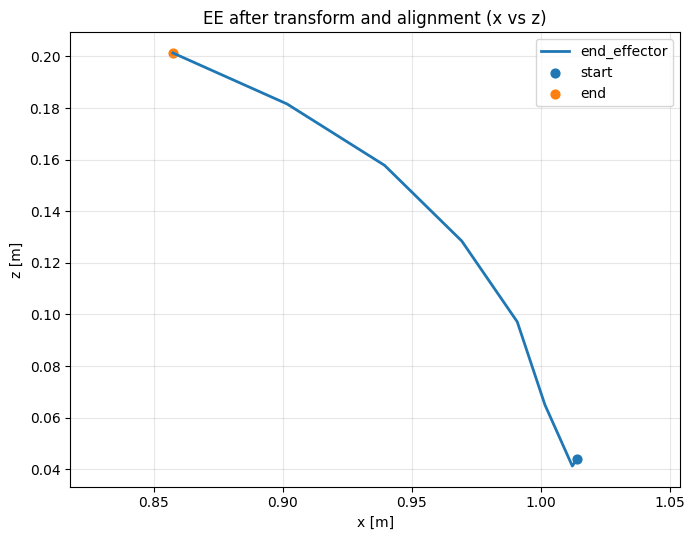

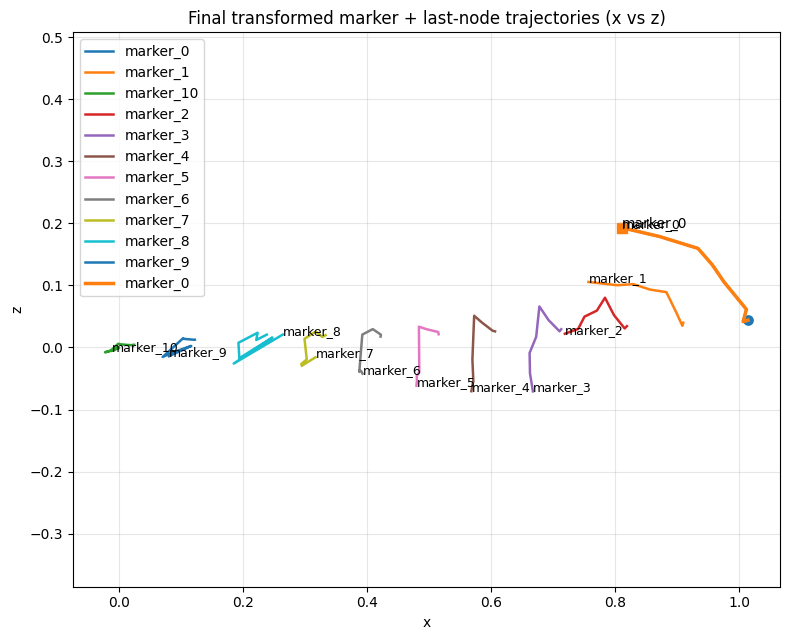

Removing NaNs: kept 8/8 timesteps
target_n_nodes: 11
use_ee_as_last_node: False
prepend_clamped_node_flag: False
append_right_ghost_clamp_flag: False
prescribe_last_two_nodes_flag: True
min_marker_presence_ratio: 0.8
qs shape: (1, 8, 43)
xb shape: (1, 8, 19)
idx_b: [ 0  1  2  3  7 11 15 19 23 27 31 35 39 40 41 42 36 37 38]
lambdas shape: (1, 8)


In [3]:
from extract_data import extract_directbc_dataset, plot_qs_snapshots
qs, xb, idx_b, lambdas = extract_directbc_dataset(input_json_path=file_path, output_npz_path=output_path, reverse_trajectory=False, make_plots=True, drop_first_points=drop_first_points, n_nodes=n_nodes, use_ee_as_last_node=False, prepend_clamped_node_flag=False, append_right_ghost_clamp_flag=False, min_marker_presence_ratio=min_marker_presence_ratio, prescribe_last_two_nodes_flag=True)

In [4]:
print(qs[0,0,:])

[0.         0.         0.         0.         0.12261423 0.
 0.01248373 0.         0.23857744 0.         0.02070258 0.
 0.33328786 0.         0.0197874  0.         0.42204463 0.
 0.01760075 0.         0.51558357 0.         0.02133538 0.
 0.60649077 0.         0.02597092 0.         0.7130841  0.
 0.02942117 0.         0.81894073 0.         0.03434472 0.
 0.90984735 0.         0.03994517 0.         1.01411279 0.
 0.0440445 ]


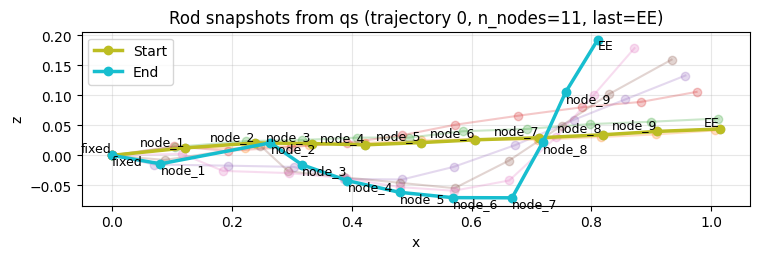

In [5]:
plot_qs_snapshots(qs, every_step=1)

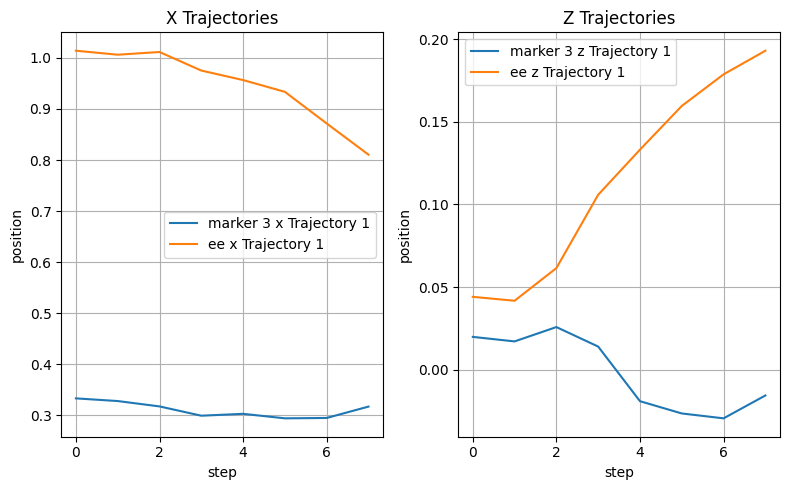

In [6]:
import matplotlib.pyplot as plt
# plot end effector and center marker trajectories for x and z directions

for i in range(qs.shape[0]):
    # separate sublots for x trajectories and z trajectories
    plt.figure(figsize=(8, 5))
    # plot x trajectories
    plt.subplot(1, 2, 1)
    plt.plot(qs[i, :, 12], label=f"marker 3 x Trajectory {i+1}")
    plt.plot(qs[i, :, -3], label=f"ee x Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("X Trajectories")
    plt.legend()
    plt.grid()

    # plot z trajectories
    plt.subplot(1, 2, 2)
    plt.plot(qs[i, :, 14], label=f"marker 3 z Trajectory {i+1}")
    plt.plot(qs[i, :, -1], label=f"ee z Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("Z Trajectories")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()